# 양자 회로의 시각화(Visual)

## 목표
- AI 실무 관점에서 양자 회로의 시각화의 목적

1. 그래프 구조의 동형성
    - 양자 회로는 본질적으로 방향성 비순환 그래프(DAG, Directed Acyclic Graph)이다.
    - 노드(게이트)들이 엣지(큐비트 선)로 연결되어 있고, 시간 순서가 부여된 구조다.
    - AI 실무에서 다루는 핵심 객체도 같은 구조를 가진다.
        - 신경망 아키텍처(레이어 -> 레이어)
        - 연산 그래프 (PyTorch/TensorFlow의 computation graph)
        - 데이터 파이프라인 (추출 -> 변환 -> 적재)
        - 워크플로우 DAG (Airflow 등)
    - 이들 모두 "노드 + 엣지 + 흐름 방향"을 가진 그래프이다.
    - 양자 회로는 규칙이 깔끔하고 시간 흐름이 명확해서, 추상적 기술을 연습하기에 좋은 교재가 될 수 있다.
    - (소결) 양자 회로를 시각화하는 연습은 AI 실무에서 자주 마주할 그래프형 구조를 시각화하는 연습이다.

2. 시각회 원리의 도메인 독립성
    - 좋은 시각화의 원리는 도메인을 가리지 않는다.
        - 객체를 시각 기호로 인코딩
        - 위치/연결로 관계 표현
        - 방향으로 순서 표현
    - (소결) 낯선 도메인에 같은 원리를 적용함으로써, "시각화는 데이터 종류에 묶이지 않는 일반 기술"이라는 점을 체득할 수 있다.

3. 양자 머신러닝
    - 양자 컴퓨팅과 AI를 직접 잇는 양자 머신러닝(QML)이라는 실제 연구 분야가 존재한다.
    - 변분 양자 회로(variational circuit)를 일종의 양자 신경망으로 쓰는 방식이다.
    - 다만 대부분 연구 단계이고 실무(production) 영역이 아니므로, AI 실무 관점에서 주된 의도일 가능성은 낮다.

- 목표
    - 오늘 배운 시각화 기술을 "그래프 구조를 가진 낯선 객체"에 적용하여 연습하는 것이 목표
    - 양자 회로를 고른 이유:
        - AI 실무자가 자주 다루는 대상(신경망, 연산 그래프, 파이프라인)과 구조적으로 같은 종류(노드 + 엣지 + 방향성 흐름)이면서
        - 규칙이 명확해 시각화 원리를 깔끔하게 연습할 수 있는 재료이기 때문
        - 시각화라는 공통 기술과 그래프 구조라는 공통 형식을 매개로 간접 연결

## 회로를 그리기 위한 기초 지식
- 양자역학을 이해하기 위한 지식이 아님
- 다이어그램을 그리기 위해, "무엇이 어떤 기호로 표현되는가"와 같은 **구조와 규약을 이해**하는 것에 중점

1. 의존성 순서에 따라 기초 개념을 표로 정리
    ```bash
    양자 회로 시각화
    ├─ Layer 0: 표현 대상 (무엇을 그리는가)
    │   ├─ 큐비트 (Qubit) ──────── 가장 먼저
    │   ├─ 게이트 (Gate)
    │   │   ├─ 단일 큐비트 게이트
    │   │   └─ 다중 큐비트 게이트
    │   └─ 측정 (Measurement)
    │
    ├─ Layer 1: 표현 규약 (어떻게 기호로 바꾸는가)
    │   ├─ 선 = 큐비트
    │   ├─ 가로축 = 시간 (왼→오른쪽)
    │   ├─ 박스/기호 = 게이트
    │   └─ 세로 연결선 = 다중 큐비트 결합
    │
    └─ Layer 2: 구조 모델 (어떻게 배치하는가)
        ├─ (큐비트 × 시간) 격자
        └─ 모먼트(moment) = 동시에 일어나는 열
    ```

2. Layer
    - Layer 0: 표현 대상
        - 무엇을 그리는지 파악하기
        - 회로를 이루는 부품 목록
            - 큐비트
                - 의미: 정보 단위
                - 시각 기호: 수평선 1개
            - H(Hadamard)
                - 의미: 중첩 생성
                - 시각 기호: H 박스
            - X, Y, Z (Pauli)
                - 의미: 비트/위상 뒤집기
                - 시각 기호: X 등 박스
            - CNOT
                - 의미: 제어-반전(얽힘 생성)
                - 시각 기호: 제어(●) — 대상(⊕)을 세로선으로 연결
            - 측정
                - 의미: 양자 -> 고전 정보
                - 시각 기호: 계측기 기호 + 이중선
        - 최소 어휘만 강조한 이유: 게이트는 수십 종이지만, 시각화 연습 단계에서 위 다섯 개 정도면 충분
        - 각 게이트가 수학적으로 무엇을 의미하는지 추후 파악해도 됨.
    
    - Layer 1: 표현 규약
        - 부품을 알았으면, 그 부품을 어떻게 종이, 화면 위 기호로 옮기는지 알아야 함.
        - 핵심 규칙 4가지
            - 큐비트 하나당 가로선 하나
            - 왼쪽이 먼저, 오른쪽이 나중 (시간 흐름)
            - 단일 게이트는 해당 선 위의 박스
            - 다중 게이트는 여러 선을 잇는 세로 연결

    - Layer 2: 구조 모델
        - 회로를 깔끔하게 그리려면 $(큐비트 = 행) x (시간 = 열)의 격자 구조$ 이해 필요
        - 각 게이트는 어느 큐피트(행)에 어느 시점(열)에 놓이는지 좌표가 정해짐.
        - 같은 열에 놓인 게이트는 "동시에 일어나는 연산(moment)"
        - DAG(방향성 비순환 그래프) 구조가 이 격자 위에 나타남.

## 시각화 연습용 회로

- 벨 상태 회로(Bell State)을 메인 회로로 구현해보기
- 가장 표준적인 회로로 검증하기 용이
- 시각화에 필요한 아래 모든 핵심 요소를 단 2개의 게이트로 연습 가능
    - 큐비트 선
    - 단일 게이트 박스
    - 다중 큐비트 세로 연결
    - 측정


/var/folders/4l/dzqs3mjj63z60y274kj7flcr0000gn/T/ipykernel_17819/1670152662.py:3: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


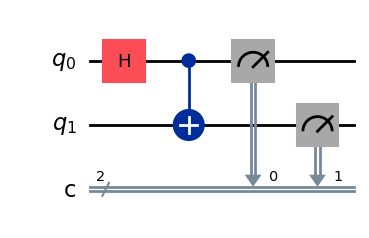

In [ ]:
# 셀 1 - 회로를 짓고 그리기
# q0 선에 H 박스 -> 제어점(●), q1 선에 대상(⊕)이 세로선으로 연결, 양쪽 끝에 측정 기호
# 가로선은 큐비트, 왼쪽→오른쪽은 시간, H는 q0에 중첩을 만들고, CNOT(●—⊕)이 두 큐비트를 얽고, 끝에서 측정
from qiskit import QuantumCircuit

qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])
qc.draw('mpl')

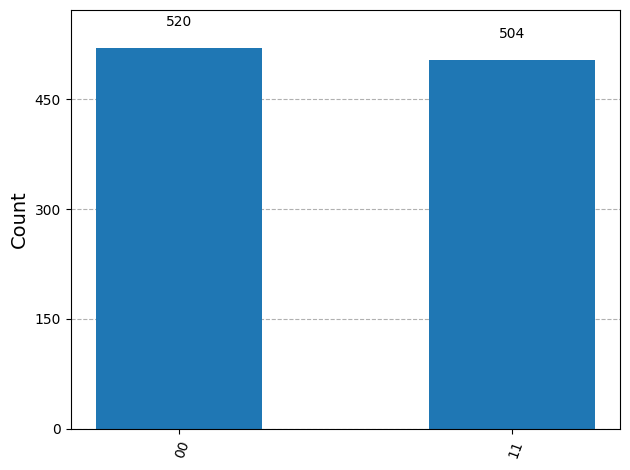

In [ ]:
# 셀 2 - 실행해서 결과까지 시각화 (선택, 얽힘 확인)
# 01이나 10이 거의 없는 형태, 00과 11 두 막대만 약 50%씩 차지하는 형태
# 두 큐비트가 얽혀서 "항상 같은 값으로 측정된다"는 의미
# 얽힘이 숫자로 확인
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()
result = sim.run(transpile(qc, sim), shots=1024).result()
counts = result.get_counts()
plot_histogram(counts)